In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Zadanie 1

Wyznacz wielomiany interpolujące funkcje
$$ f_1(x) = \frac{1}{1+25x^2} \text{ na przedziale } [-1, 1] \ , $$
$$ f_2(x) = \exp{(\cos{(x)})} \text{ na przedziale } [0, 2\pi] \ , $$
używając:
- wielomianów Lagrange'a z równoodległymi węzłami $ x_j = x_0 + jh, \ j = 0, 1, ..., n, \text{ gdzie } h = (x_n - x_0)/n$
- kubicznych funkcji sklejanych z równoodległymi węzłami $ x_j = x_0 + jh, \ j = 0, 1, ..., n, \text{ gdzie } h = (x_n - x_0)/n$
- wielomianów Lagrange'a z węzłami Czebyszewa $$ x_j = \cos{(\theta_j)} \ \ \ \theta_j = \frac{2j+1}{2n}\pi \ , \ 0 \le j < n \ . \tag{1} $$ 

In [2]:
def f1(x):
    return 1 / (1 + 25 * x**2)


def f2(x):
    return np.exp(np.cos(x))


vf1 = np.vectorize(f1, otypes=[np.float64])
vf2 = np.vectorize(f2, otypes=[np.float64])

In [3]:
def lagrange_interpolation(x, xs, ys):
    def L(k, x):
        result = 1
        for i, xi in enumerate(xs):
            if i != k:
                result *= (x - xi) / (xs[k] - xi)
        return result

    def P(x):
        result = 0
        for k in range(len(xs)):
            result += ys[k] * L(k, x)
        return result

    return P(x)

In [4]:
def chebyshev_nodes(a, b, n):
    def xj(j, n):
        phi = (2 * j + 1) / (2 * n) * np.pi
        return np.cos(phi)

    def transform(r, a, b):
        return a + (b - a) * (r + 1) / 2

    vxj = np.vectorize(xj, otypes=[np.float64], excluded=["n"])
    vtransform = np.vectorize(transform, otypes=[np.float64], excluded=["a", "b"])
    js = np.arange(0, n)

    if (a, b) == (-1, 1):
        return vxj(js, n)
    return vtransform(vxj(js, n), a, b)

### a)

Dla funkcji Rungego, $ f_1(x) $, z $ n = 12 $ węzłami interpolacji przedstaw na wspólnym wykresie funkcję $ f_1(x) $ oraz wyznaczone wielomiany interpolacyjne i funkcję sklejaną. W celu stworzenia wykresu wykonaj próbkowanie funkcji $ f_1(x) $ i wielomianów interpolacyjnych na $ 10 $ razy gęstszym zbiorze (próbkowanie jednostajne w $ x $ dla węzłów równoodległych, jednostajne w $ \theta $ dla węzłów Czebyszewa). Pamiętaj o podpisaniu wykresu i osi oraz o legendzie.

In [5]:
# Lagrange
xs = np.linspace(-1, 1, 12)
ys = vf1(xs)
# Lagrange Chebyshev
xs_ch = chebyshev_nodes(-1, 1, 12)
ys_ch = vf1(xs_ch)
# Sample
xs_sample = np.linspace(-1, 1, 120)

In [6]:
ys_lagrange = lagrange_interpolation(xs_sample, xs, ys)
ys_cubic_spline = interp1d(xs, ys, kind="cubic")(xs_sample)
ys_chebychev_lagrange = lagrange_interpolation(xs_sample, xs_ch, ys_ch)

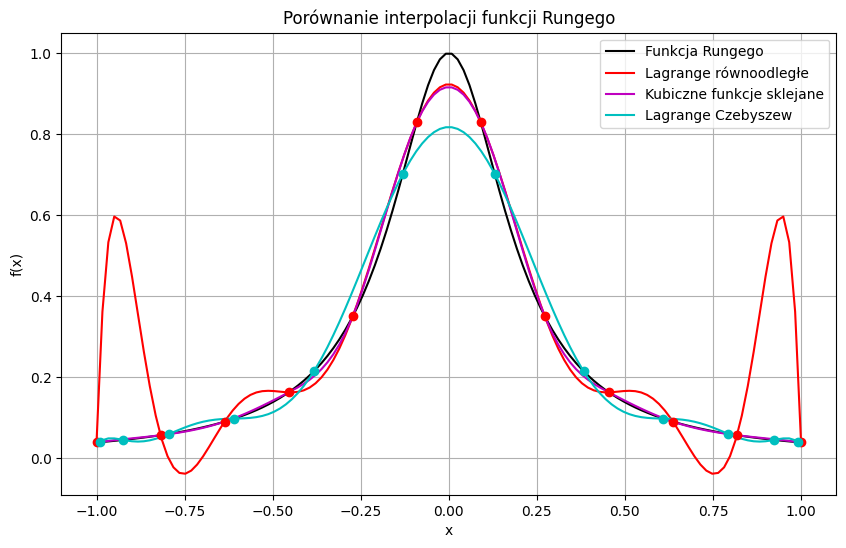

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(xs_sample, vf1(xs_sample), "k", label="Funkcja Rungego")
plt.plot(xs_sample, ys_lagrange, "r", label="Lagrange równoodległe")
plt.plot(xs_sample, ys_cubic_spline, "m", label="Kubiczne funkcje sklejane")
plt.plot(xs_sample, ys_chebychev_lagrange, "c", label="Lagrange Czebyszew")
plt.plot(xs, ys, "ro")
plt.plot(xs_ch, ys_ch, "co")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Porównanie interpolacji funkcji Rungego")
plt.grid(True)
plt.legend()
plt.show()

### b)

Wykonaj interpolację funkcji $ f_1(x) $ i $ f_2(x) $ z $ n = 4, 5, ..., 50 $ węzłami interpolacji, używając każdej z powyższych trzech metod interpolacji. Ewaluację funkcji, wielomianów interpolacyjnych oraz funkcji sklejanych przeprowadź na zbiorze $ 500 $ losowo wybranych punktów z dziedziny funkcji. Stwórz dwa rysunki, jeden dla $ f_1(x) $, drugi dla $ f_2(x) $. Na każdym rysunku przedstaw razem wykresy normy wektora błędów (czyli długości wektora) na tym zbiorze punktów w zależności od liczby węzłów interpolacji, $ n $, dla każdej z trzech metod interpolacji.

In [8]:
interpolation_nodes = np.arange(4, 51)

xs_sample_f1 = np.random.uniform(-1, 1, size=500)

xs_sample_f2 = np.random.uniform(0, 2 * np.pi, size=500)

error_lagrange_f1 = np.empty(interpolation_nodes.size, dtype=np.float64)
error_cubic_spline_f1 = np.empty(interpolation_nodes.size, dtype=np.float64)
error_chebychev_lagrange_f1 = np.empty(interpolation_nodes.size, dtype=np.float64)

error_lagrange_f2 = np.empty(interpolation_nodes.size, dtype=np.float64)
error_cubic_spline_f2 = np.empty(interpolation_nodes.size, dtype=np.float64)
error_chebychev_lagrange_f2 = np.empty(interpolation_nodes.size, dtype=np.float64)

In [9]:
for i, n in enumerate(interpolation_nodes):
    xs = np.linspace(-1, 1, n)
    ys = vf1(xs)

    xs_ch = chebyshev_nodes(-1, 1, n)
    ys_ch = vf1(xs_ch)

    ys_lagrange = lagrange_interpolation(xs_sample_f1, xs, ys)
    ys_cubic_spline = interp1d(xs, ys, kind="cubic")(xs_sample_f1)
    ys_chebychev_lagrange = lagrange_interpolation(xs_sample_f1, xs_ch, ys_ch)

    error_lagrange_f1[i] = np.linalg.norm(np.abs(ys_lagrange - vf1(xs_sample_f1)))
    error_cubic_spline_f1[i] = np.linalg.norm(
        np.abs(ys_cubic_spline - vf1(xs_sample_f1))
    )
    error_chebychev_lagrange_f1[i] = np.linalg.norm(
        np.abs(ys_chebychev_lagrange - vf1(xs_sample_f1))
    )

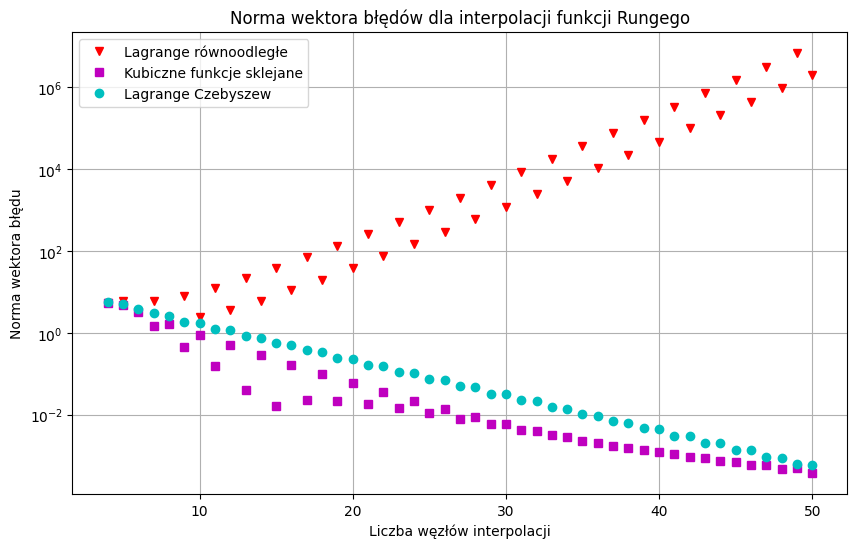

In [10]:
plt.figure(figsize=(10, 6))
plt.semilogy(
    interpolation_nodes,
    error_lagrange_f1,
    "rv",
    label="Lagrange równoodległe",
)
plt.semilogy(
    interpolation_nodes,
    error_cubic_spline_f1,
    "ms",
    label="Kubiczne funkcje sklejane",
)
plt.semilogy(
    interpolation_nodes,
    error_chebychev_lagrange_f1,
    "co",
    label="Lagrange Czebyszew",
)
plt.xlabel("Liczba węzłów interpolacji")
plt.ylabel("Norma wektora błędu")
plt.title("Norma wektora błędów dla interpolacji funkcji Rungego")
plt.grid(True)
plt.legend()
plt.show()

In [11]:
for i, n in enumerate(interpolation_nodes):
    xs = np.linspace(0, 2 * np.pi, n)
    ys = vf2(xs)

    xs_ch = chebyshev_nodes(0, 2 * np.pi, n)
    ys_ch = vf2(xs_ch)

    ys_lagrange = lagrange_interpolation(xs_sample_f2, xs, ys)
    ys_cubic_spline = interp1d(xs, ys, kind="cubic")(xs_sample_f2)
    ys_chebychev_lagrange = lagrange_interpolation(xs_sample_f2, xs_ch, ys_ch)

    error_lagrange_f2[i] = np.linalg.norm(np.abs(ys_lagrange - vf2(xs_sample_f2)))
    error_cubic_spline_f2[i] = np.linalg.norm(
        np.abs(ys_cubic_spline - vf2(xs_sample_f2))
    )
    error_chebychev_lagrange_f2[i] = np.linalg.norm(
        np.abs(ys_chebychev_lagrange - vf2(xs_sample_f2))
    )

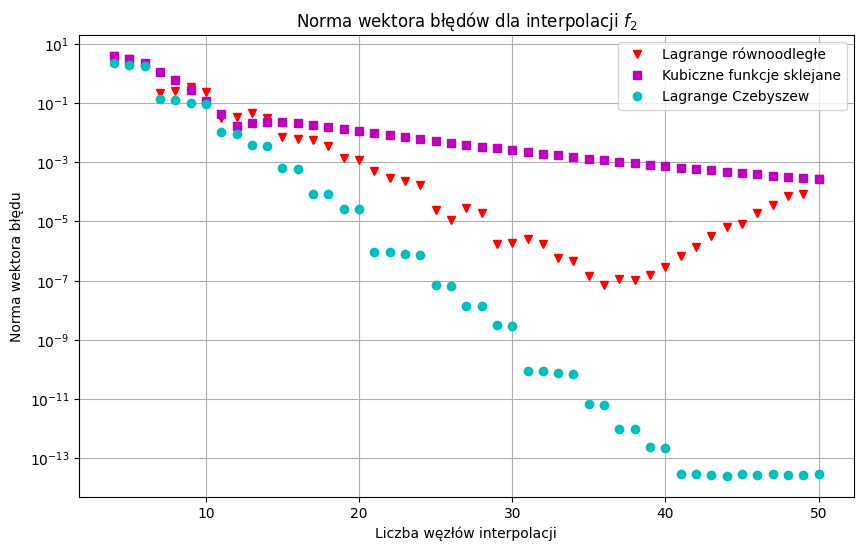

In [12]:
plt.figure(figsize=(10, 6))
plt.semilogy(
    interpolation_nodes,
    error_lagrange_f2,
    "rv",
    label="Lagrange równoodległe",
)
plt.semilogy(
    interpolation_nodes,
    error_cubic_spline_f2,
    "ms",
    label="Kubiczne funkcje sklejane",
)
plt.semilogy(
    interpolation_nodes,
    error_chebychev_lagrange_f2,
    "co",
    label="Lagrange Czebyszew",
)
plt.xlabel("Liczba węzłów interpolacji")
plt.ylabel("Norma wektora błędu")
plt.title("Norma wektora błędów dla interpolacji $f_2$")
plt.grid(True)
plt.legend()
plt.show()

Która metoda interpolacji jest najbardziej dokładna, a która najmniej?

*Uwaga 1.* Transformacja węzłów Czebyszewa $ r \in [-1, 1] $ na punkty $ x \in [a, b] $ dana jest wzorem $ x = a + (b - a) * (r + 1) / 2 $ .

*Uwaga 2.* Interpolację funkcjami sklejanymi można zaimplementować funkcją `scipy.interpolate.interp1d`. Zaimplementuj własnoręcznie interpolację Lagrange’a. Interpolacja Lagrange’a, w tym implementacja biblioteczna `scipy.interpolate.lagrange` jest niestablina numerycznie.